In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# TorchVision
import torchvision.transforms.v2 as v2
from torchvision.models import inception_v3, resnet50, efficientnet_b4, EfficientNet_B4_Weights, ResNet50_Weights, Inception_V3_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# Data utilities
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from tqdm import tqdm

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [ ]:
MAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face Age Dataset"
TRAIN_PATH = os.path.join(MAIN_PATH,"train")
TEST_PATH = os.path.join(MAIN_PATH,"test")

IMG_SIZE = 224

EPOCHS = 10
BATCH_SIZE = 128
PATIENCE = 3

LR = 1e-4

SPLIT_PARAM = [0.8,0.2]

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

df = pd.read_csv(os.path.join(MAIN_PATH,"age_detection.csv"))
df

,file,age,split
0,train/18-20/0.jpg,18-20,train
1,train/18-20/1.jpg,18-20,train
2,train/18-20/2.jpg,18-20,train
3,train/18-20/3.jpg,18-20,train
4,train/18-20/4.jpg,18-20,train
...,...,...,...
145,test/51-60/25.jpg,51-60,test
146,test/51-60/26.jpg,51-60,test
147,test/51-60/27.jpg,51-60,test
148,test/51-60/28.jpg,51-60,test


In [5]:
labels = set(df["age"].values)
labels

{'18-20', '21-30', '31-40', '41-50', '51-60'}

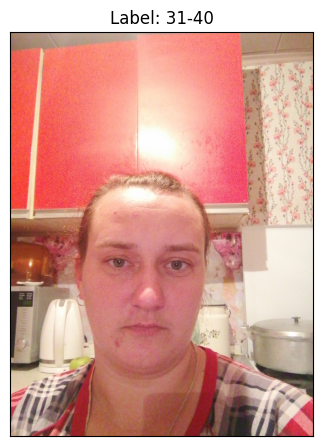

In [ ]:
def show_img():
    img_path = np.random.choice(df["file"].values)
    plt.imshow(plt.imread(os.path.join(MAIN_PATH,img_path)))
    plt.title(f"Label: {img_path.split('/')[1]}")
    plt.tight_layout()
    plt.yticks([])
    plt.xticks([])
    plt.show()

show_img()